In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyvalet import ValetInterpreter


In [2]:
vi = ValetInterpreter()

In [3]:
# V39079: Bank of Canada Policy Target Rate (Interest Rate)
# V41690973: Consumer Price Index (CPI) Total, Monthly, Not Seasonally Adjusted
series_map = {
    "policy_interest_rate" : "V39079",
    "cpi_total" : "V41690973"
}

# Raw Target Overnight Interest Rate Data
target_overnight_interest_rate = vi.get_series_observations(series_map["policy_interest_rate"], "csv").drop(np.nan, axis=1)
target_overnight_interest_rate = target_overnight_interest_rate.rename(columns={"date": "Date", "V39079": "Interest Rate"})
target_overnight_interest_rate["Date"] = pd.to_datetime(target_overnight_interest_rate["Date"])
target_overnight_interest_rate["Interest Rate"] = pd.to_numeric(target_overnight_interest_rate["Interest Rate"])

# Raw Consumer Price Index
consumer_price_index = vi.get_series_observations(series_map["cpi_total"], "csv").drop(np.nan, axis=1)
consumer_price_index = consumer_price_index.rename(columns={"date": "Date", "V41690973": "Consumer Price Index"})
consumer_price_index["Date"] = pd.to_datetime(consumer_price_index["Date"])
consumer_price_index["Consumer Price Index"] = pd.to_numeric(consumer_price_index["Consumer Price Index"])

In [4]:
# Inorder to plot the two dataframes on the same plot we need to align them and merge
cpi_w_interest_rate = pd.merge(target_overnight_interest_rate, consumer_price_index, on="Date", how="inner")

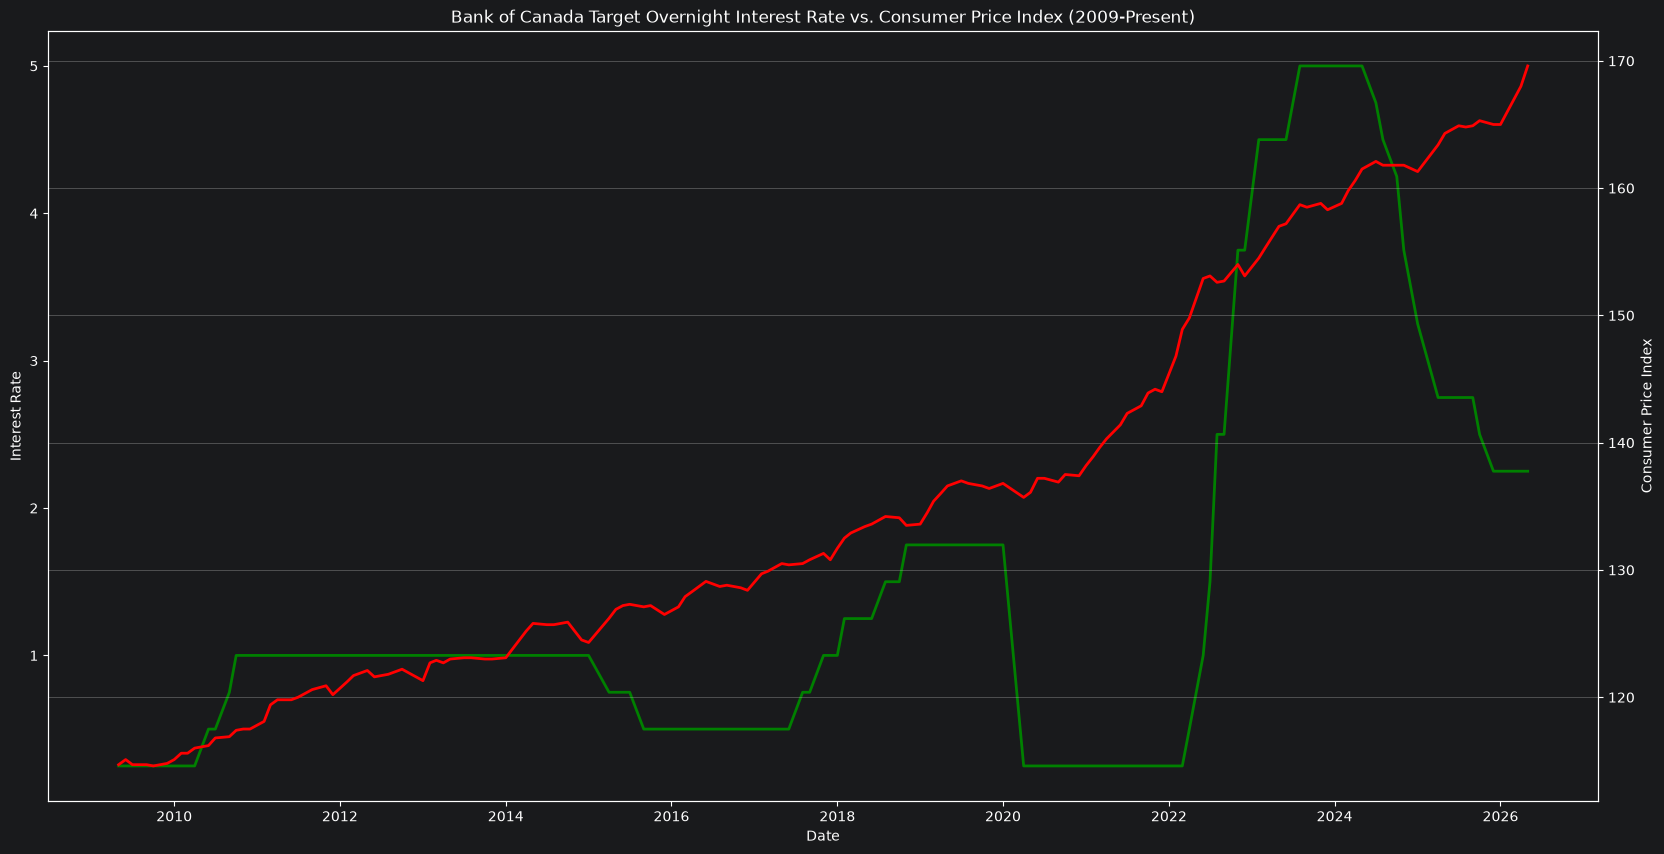

In [25]:
fig, ax1 = plt.subplots(figsize=(20,10))

# Interest Rate Line
ax1.set_xlabel("Date")
ax1.plot(cpi_w_interest_rate["Date"], cpi_w_interest_rate["Interest Rate"], color='g', linewidth='2')
ax1.set_ylabel("Interest Rate")

# Consumer Price Line
ax2 = ax1.twinx()
ax2.plot(cpi_w_interest_rate["Date"], cpi_w_interest_rate["Consumer Price Index"], color='r', linewidth='2')
ax2.grid(True)
ax2.set_ylabel("Consumer Price Index")

plt.title("Bank of Canada Target Overnight Interest Rate vs. Consumer Price Index (2009-Present)")
plt.show()




In [6]:
consumer_price_index["Inflation Rate"] = consumer_price_index["Consumer Price Index"].pct_change(periods=12)*100
consumer_price_index = consumer_price_index.dropna()

cpi_inflation_interest = pd.merge(target_overnight_interest_rate, consumer_price_index, on="Date", how="inner")

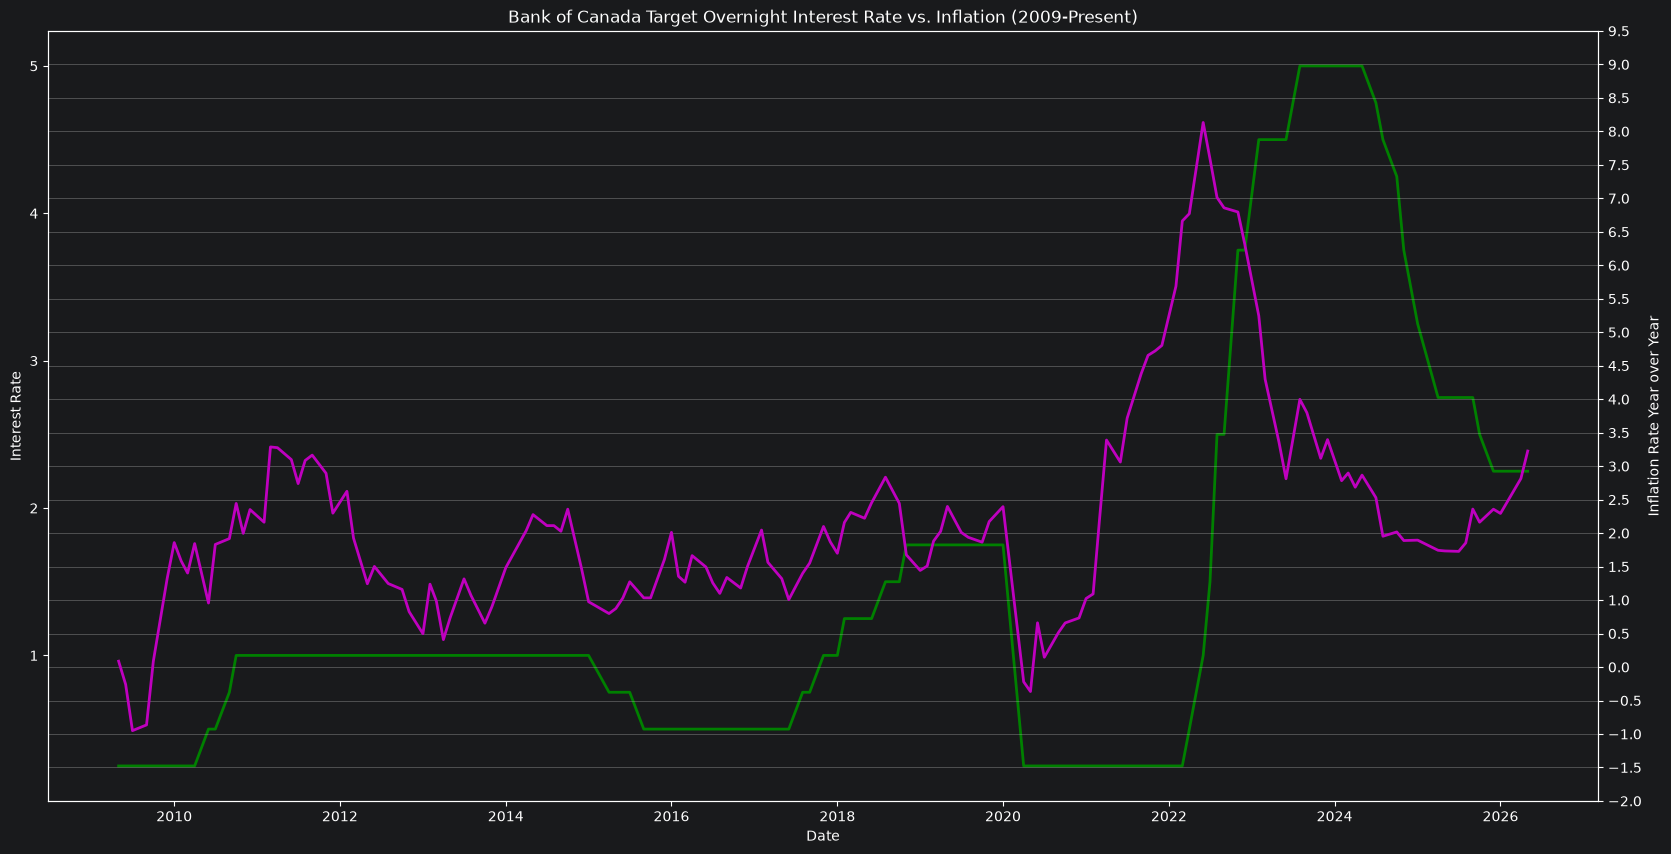

In [23]:
fig, ax1 = plt.subplots(figsize=(20,10))

# Interest Rate Line
ax1.set_xlabel("Date")
ax1.plot(cpi_inflation_interest["Date"], cpi_inflation_interest["Interest Rate"], color='g', linewidth='2')
ax1.set_ylabel("Interest Rate")

# Consumer Price Line
ax2 = ax1.twinx()
ax2.plot(cpi_inflation_interest["Date"], cpi_inflation_interest["Inflation Rate"], color='m', linewidth='2')
ax2.set_yticks(np.arange(-2, 10, 0.5))
ax2.grid(True)
ax2.set_ylabel("Inflation Rate Year over Year")

plt.title("Bank of Canada Target Overnight Interest Rate vs. Inflation (2009-Present)")
plt.show()